In [ ]:
# Install PyTorch + PyG
!pip install torch torchvision torchaudio
!pip install torch-geometric open3d tqdm wandb huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.5 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import os
import glob
import zipfile
import random

import numpy as np
import open3d as o3d

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import wandb
from huggingface_hub import hf_hub_download

In [ ]:
CFG = {

    "data_dir": "data/MaizeField",

    "num_points": 2048,
    "batch_size": 8,

    "epochs": 500,
    "lr": 3e-4,

    "latent_dim": 256,
    "k": 16,

    "train_plants": 500,
    "val_plants": 200,
    "test_plants": 300,

    "checkpoint_interval": 25
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cuda


In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shantanugupta2004 (shantanugupta2004-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project="maizefield-pointnetpp-ae-log",
    config=CFG
)

In [ ]:
os.makedirs("data", exist_ok=True)

zip_path = hf_hub_download(
    repo_id="BGLab/MaizeField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="data"
)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(CFG["data_dir"])

ply_files = sorted(glob.glob(f"{CFG['data_dir']}/**/*.ply", recursive=True))

print("Total plants:", len(ply_files))

datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Total plants: 1045


In [ ]:
random.seed(42)
random.shuffle(ply_files)

train_files = ply_files[:CFG["train_plants"]]
val_files = ply_files[CFG["train_plants"]:CFG["train_plants"]+CFG["val_plants"]]
test_files = ply_files[CFG["train_plants"]+CFG["val_plants"]:
                       CFG["train_plants"]+CFG["val_plants"]+CFG["test_plants"]]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 500
Val: 200
Test: 300


In [ ]:
def normalize_pc(pc):

    pc = pc - pc.mean(axis=0)
    scale = np.sqrt((pc**2).sum(axis=1)).max()

    pc = pc / scale

    return pc


def sample_points(pc, n):

    idx = np.random.choice(pc.shape[0], n, replace=False)

    return pc[idx]

In [ ]:
class MaizeDataset(Dataset):

    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        pcd = o3d.io.read_point_cloud(self.files[idx])

        points = np.asarray(pcd.points)

        points = normalize_pc(points)
        points = sample_points(points, CFG["num_points"])

        return torch.tensor(points, dtype=torch.float32)

In [ ]:
train_dataset = MaizeDataset(train_files)
val_dataset = MaizeDataset(val_files)
test_dataset = MaizeDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG["batch_size"], shuffle=False)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(3, 64, 1), nn.BatchNorm1d(64), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv1d(256, latent_dim, 1), nn.BatchNorm1d(latent_dim), nn.ReLU())

    def forward(self, x):
        x = x.transpose(2, 1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return torch.max(x, 2)[0]

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, num_points):
        super().__init__()
        self.n = num_points

        grid_size = int(np.sqrt(num_points)) + 1
        grid = np.meshgrid(np.linspace(-1, 1, grid_size), np.linspace(-1, 1, grid_size))
        grid = np.stack(grid, axis=-1).reshape(-1, 2)[:num_points]

        self.register_buffer('grid', torch.FloatTensor(grid).unsqueeze(0))

        self.fold1 = nn.Sequential(
            nn.Linear(latent_dim + 2, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 3)
        )

        self.fold2 = nn.Sequential(
            nn.Linear(latent_dim + 3, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 3)
        )

    def forward(self, latent):

        batch_size = latent.size(0)

        x = latent.unsqueeze(1).repeat(1, self.n, 1)

        grid = self.grid.repeat(batch_size, 1, 1)

        pc1 = self.fold1(torch.cat([x, grid], dim=2))

        pc2 = self.fold2(torch.cat([x, pc1], dim=2))

        return pc2

In [ ]:
class FoldingNetAE(nn.Module):

    def __init__(self, latent_dim, num_points):

        super().__init__()

        self.encoder = Encoder(latent_dim)

        self.decoder = Decoder(latent_dim, num_points)

    def forward(self, x):

        latent = self.encoder(x)

        recon = self.decoder(latent)

        return recon

In [ ]:
def chamfer_loss(pc1, pc2):

    diff = pc1.unsqueeze(2) - pc2.unsqueeze(1)

    dist = torch.sum(diff**2, dim=-1)

    loss1 = dist.min(dim=2)[0].mean()

    loss2 = dist.min(dim=1)[0].mean()

    return loss1 + loss2

In [ ]:
model = FoldingNetAE(CFG["latent_dim"], CFG["num_points"]).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=CFG["lr"])

In [ ]:
def evaluate(model, loader):

    model.eval()

    total = 0

    with torch.no_grad():

        for pc in loader:

            pc = pc.to(DEVICE)

            recon = model(pc)

            loss = chamfer_loss(pc, recon)

            total += loss.item()

    return total / len(loader)

In [ ]:
import matplotlib.pyplot as plt
def visualize_reconstruction(model, dataset):

    model.eval()

    idx = np.random.randint(len(dataset))

    pc = dataset[idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        recon = model(pc)

    pc = pc.squeeze().cpu().numpy()

    recon = recon.squeeze().cpu().numpy()

    fig = plt.figure(figsize=(12,6))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(pc[:,0], pc[:,1], pc[:,2], s=2, c=pc[:,2], cmap="viridis")
    ax1.set_title("Original")

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(recon[:,0], recon[:,1], recon[:,2], s=2, c=recon[:,2], cmap="viridis")
    ax2.set_title("Reconstruction")

    plt.show()

    return fig

100%|██████████| 63/63 [00:06<00:00, 10.32it/s]


Epoch 0 Train 0.2681 Val 0.2312


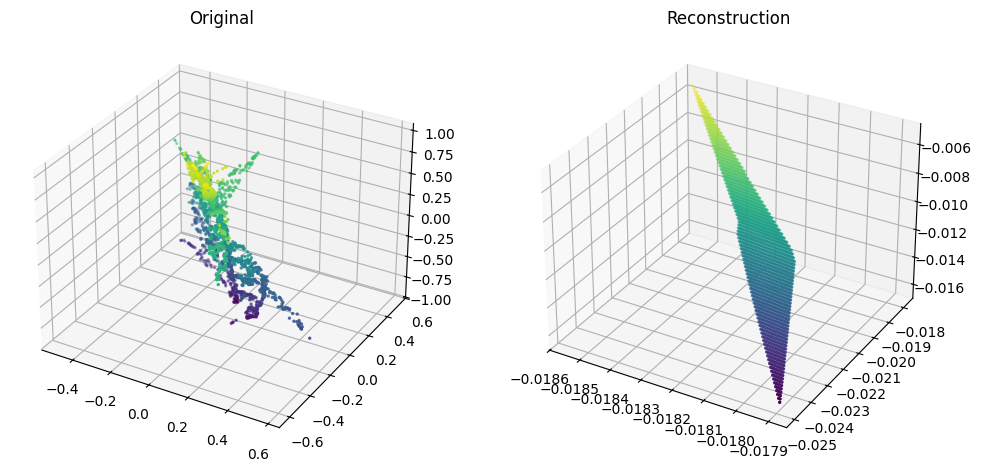

100%|██████████| 63/63 [00:04<00:00, 13.97it/s]


Epoch 1 Train 0.1509 Val 0.0572


100%|██████████| 63/63 [00:04<00:00, 12.86it/s]


Epoch 2 Train 0.0588 Val 0.0546


100%|██████████| 63/63 [00:04<00:00, 13.13it/s]


...

Epoch 23 Train 0.0108 Val 0.0124


100%|██████████| 63/63 [00:04<00:00, 12.93it/s]


Epoch 24 Train 0.0108 Val 0.0121


100%|██████████| 63/63 [00:05<00:00, 12.23it/s]


Epoch 25 Train 0.0106 Val 0.0122


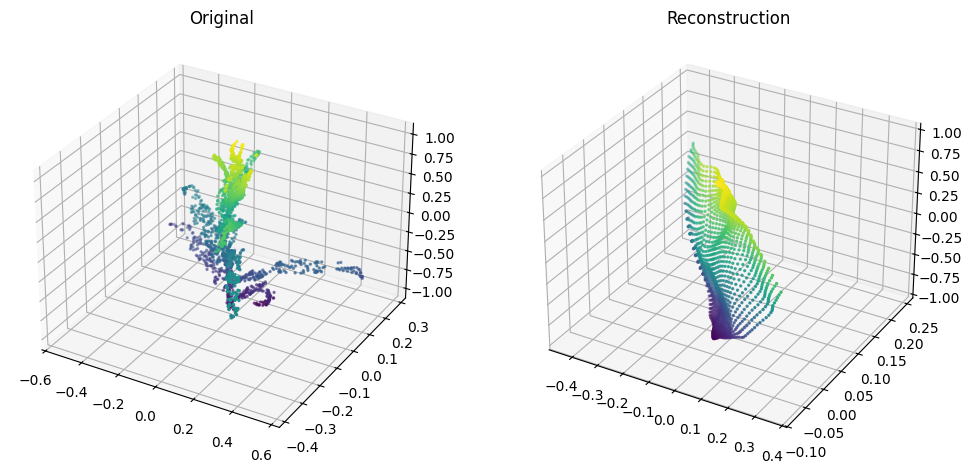

100%|██████████| 63/63 [00:04<00:00, 12.90it/s]


Epoch 26 Train 0.0104 Val 0.0118


100%|██████████| 63/63 [00:05<00:00, 12.29it/s]


Epoch 27 Train 0.0100 Val 0.0109


100%|██████████| 63/63 [00:04<00:00, 12.94it/s]


...

Epoch 48 Train 0.0068 Val 0.0079


100%|██████████| 63/63 [00:04<00:00, 12.91it/s]


Epoch 49 Train 0.0067 Val 0.0084


100%|██████████| 63/63 [00:05<00:00, 12.19it/s]


Epoch 50 Train 0.0067 Val 0.0081


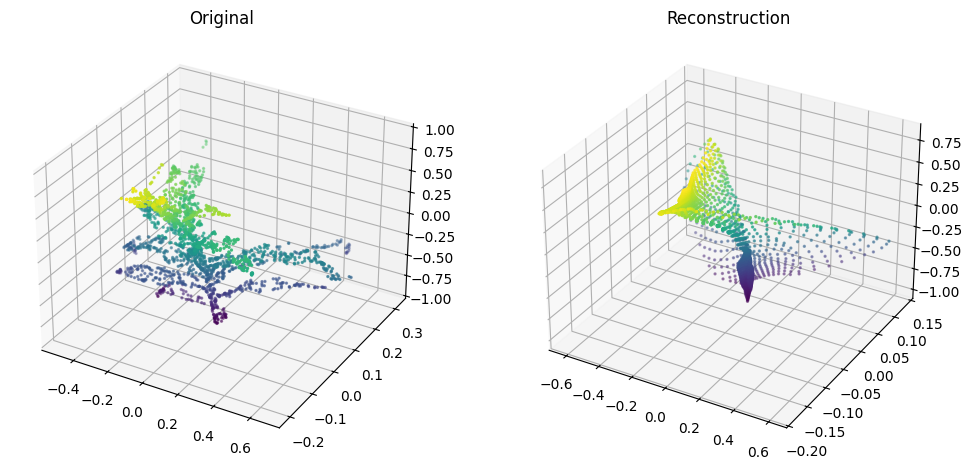

100%|██████████| 63/63 [00:04<00:00, 12.83it/s]


Epoch 51 Train 0.0066 Val 0.0078


100%|██████████| 63/63 [00:05<00:00, 12.00it/s]


Epoch 52 Train 0.0063 Val 0.0082


100%|██████████| 63/63 [00:04<00:00, 12.80it/s]


...

Epoch 73 Train 0.0057 Val 0.0075


100%|██████████| 63/63 [00:04<00:00, 12.77it/s]


Epoch 74 Train 0.0057 Val 0.0074


100%|██████████| 63/63 [00:05<00:00, 12.18it/s]


Epoch 75 Train 0.0057 Val 0.0069


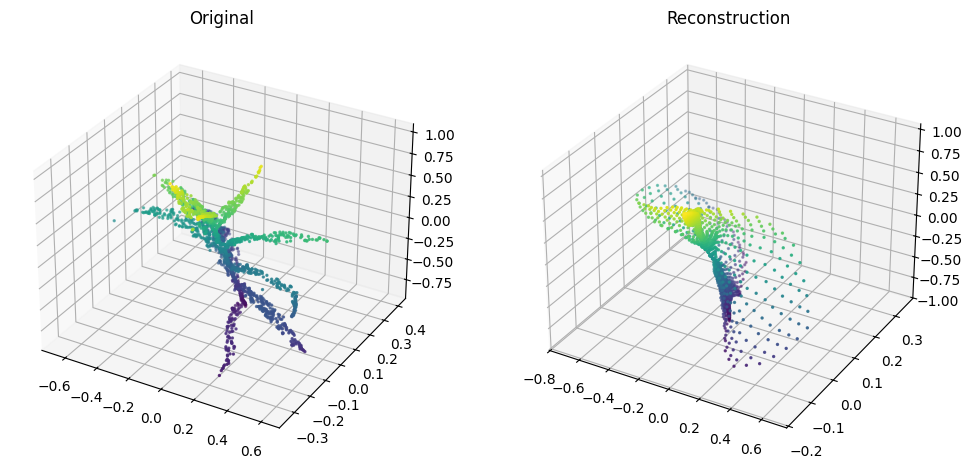

100%|██████████| 63/63 [00:04<00:00, 12.77it/s]


Epoch 76 Train 0.0057 Val 0.0074


100%|██████████| 63/63 [00:05<00:00, 12.11it/s]


Epoch 77 Train 0.0057 Val 0.0075


100%|██████████| 63/63 [00:04<00:00, 12.76it/s]


...

Epoch 98 Train 0.0052 Val 0.0066


100%|██████████| 63/63 [00:05<00:00, 12.51it/s]


Epoch 99 Train 0.0049 Val 0.0071


100%|██████████| 63/63 [00:05<00:00, 12.41it/s]


Epoch 100 Train 0.0049 Val 0.0073


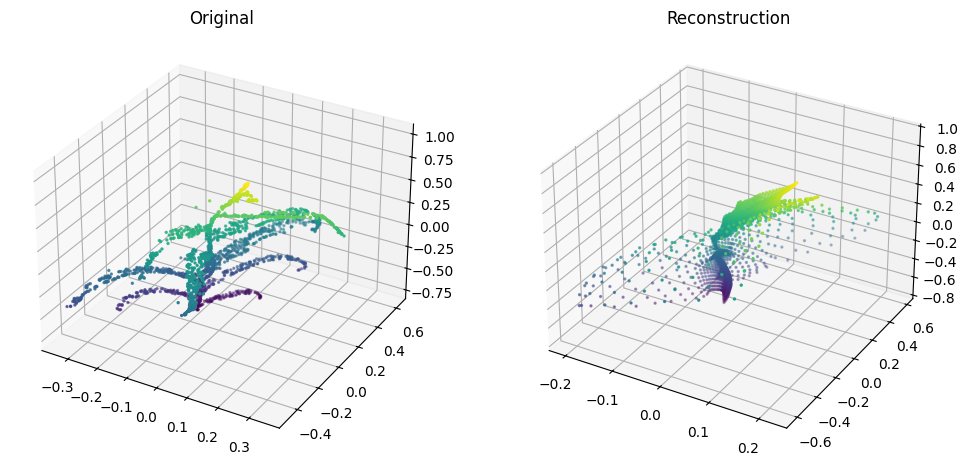

100%|██████████| 63/63 [00:05<00:00, 12.33it/s]


Epoch 101 Train 0.0052 Val 0.0066


100%|██████████| 63/63 [00:05<00:00, 11.95it/s]


Epoch 102 Train 0.0050 Val 0.0074


100%|██████████| 63/63 [00:05<00:00, 12.44it/s]


...

Epoch 123 Train 0.0044 Val 0.0060


100%|██████████| 63/63 [00:05<00:00, 12.25it/s]


Epoch 124 Train 0.0045 Val 0.0059


100%|██████████| 63/63 [00:04<00:00, 12.70it/s]


Epoch 125 Train 0.0045 Val 0.0067


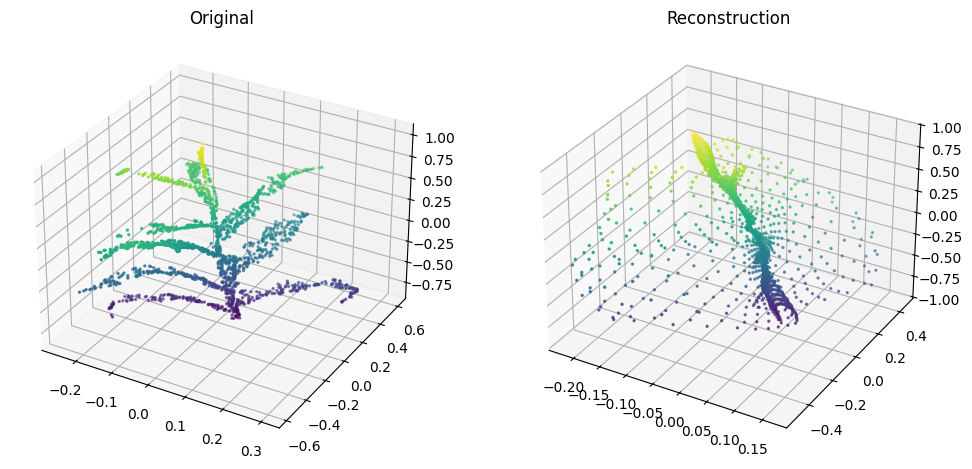

100%|██████████| 63/63 [00:05<00:00, 12.43it/s]


Epoch 126 Train 0.0045 Val 0.0060


100%|██████████| 63/63 [00:05<00:00, 12.40it/s]


Epoch 127 Train 0.0044 Val 0.0060


100%|██████████| 63/63 [00:04<00:00, 12.62it/s]


...

Epoch 148 Train 0.0041 Val 0.0059


100%|██████████| 63/63 [00:05<00:00, 12.10it/s]


Epoch 149 Train 0.0046 Val 0.0064


100%|██████████| 63/63 [00:04<00:00, 12.65it/s]


Epoch 150 Train 0.0045 Val 0.0060


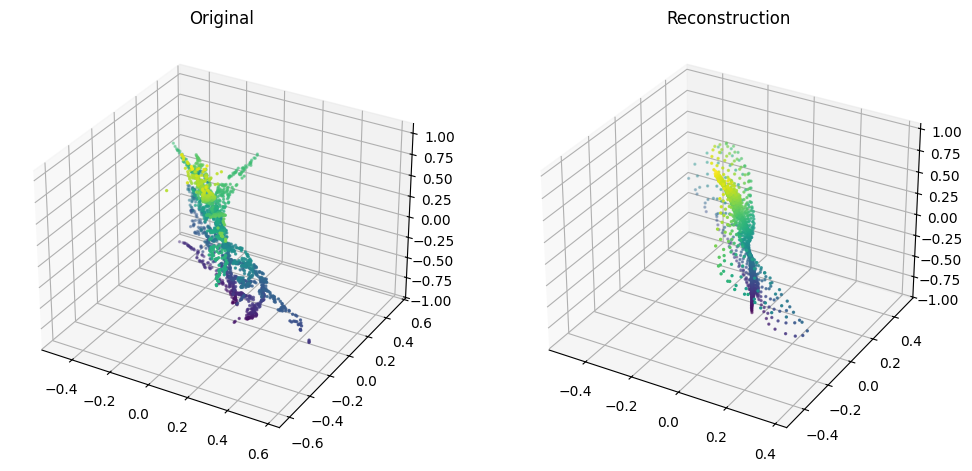

100%|██████████| 63/63 [00:05<00:00, 12.21it/s]


Epoch 151 Train 0.0041 Val 0.0058


100%|██████████| 63/63 [00:05<00:00, 12.54it/s]


Epoch 152 Train 0.0042 Val 0.0062


100%|██████████| 63/63 [00:05<00:00, 12.33it/s]


...

Epoch 173 Train 0.0036 Val 0.0056


100%|██████████| 63/63 [00:05<00:00, 12.11it/s]


Epoch 174 Train 0.0036 Val 0.0057


100%|██████████| 63/63 [00:05<00:00, 12.51it/s]


Epoch 175 Train 0.0037 Val 0.0057


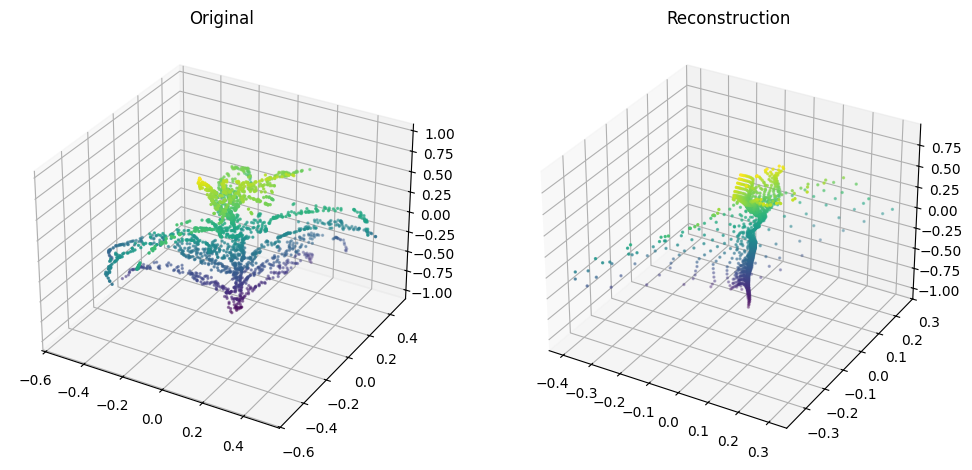

100%|██████████| 63/63 [00:05<00:00, 12.01it/s]


Epoch 176 Train 0.0039 Val 0.0062


100%|██████████| 63/63 [00:05<00:00, 12.49it/s]


Epoch 177 Train 0.0037 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.33it/s]


...

Epoch 198 Train 0.0037 Val 0.0057


100%|██████████| 63/63 [00:05<00:00, 12.06it/s]


Epoch 199 Train 0.0037 Val 0.0057


100%|██████████| 63/63 [00:04<00:00, 12.64it/s]


Epoch 200 Train 0.0034 Val 0.0056


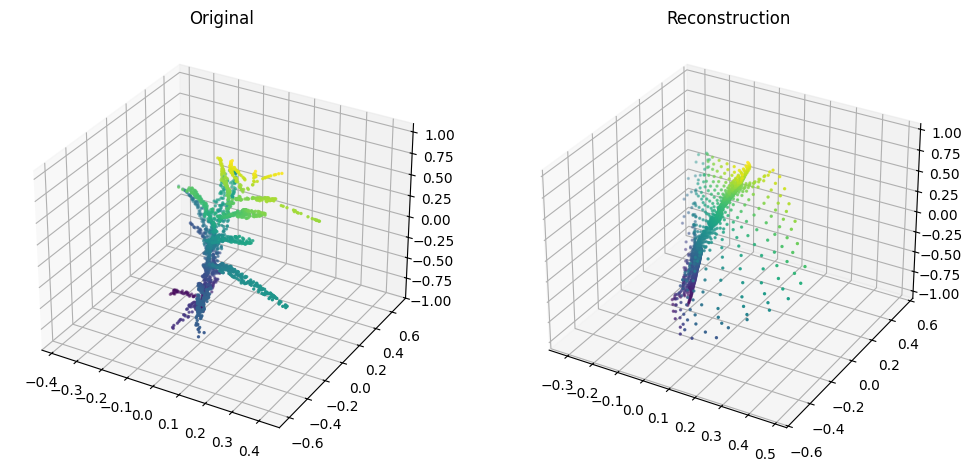

100%|██████████| 63/63 [00:05<00:00, 12.30it/s]


Epoch 201 Train 0.0035 Val 0.0055


100%|██████████| 63/63 [00:04<00:00, 12.63it/s]


Epoch 202 Train 0.0035 Val 0.0057


100%|██████████| 63/63 [00:05<00:00, 12.57it/s]


...

Epoch 223 Train 0.0032 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.35it/s]


Epoch 224 Train 0.0033 Val 0.0055


100%|██████████| 63/63 [00:05<00:00, 12.48it/s]


Epoch 225 Train 0.0032 Val 0.0054


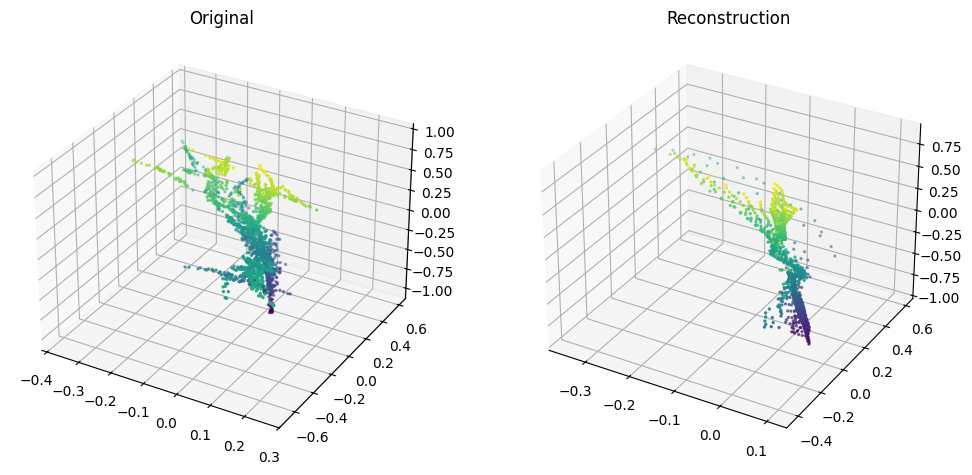

100%|██████████| 63/63 [00:05<00:00, 12.47it/s]


Epoch 226 Train 0.0033 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.27it/s]


Epoch 227 Train 0.0033 Val 0.0055


100%|██████████| 63/63 [00:05<00:00, 12.57it/s]


...

Epoch 248 Train 0.0031 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.38it/s]


Epoch 249 Train 0.0031 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.43it/s]


Epoch 250 Train 0.0030 Val 0.0054


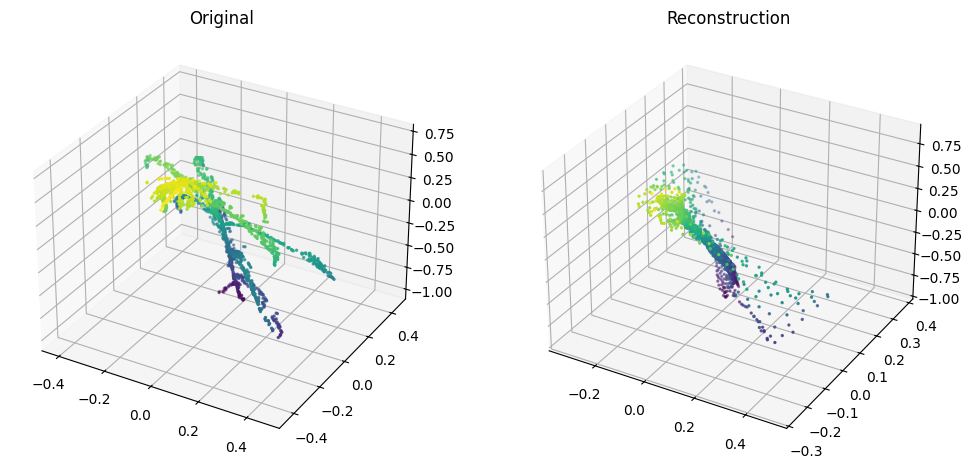

100%|██████████| 63/63 [00:05<00:00, 12.54it/s]


Epoch 251 Train 0.0031 Val 0.0057


100%|██████████| 63/63 [00:05<00:00, 12.25it/s]


Epoch 252 Train 0.0030 Val 0.0056


100%|██████████| 63/63 [00:04<00:00, 12.73it/s]


...

Epoch 273 Train 0.0029 Val 0.0056


100%|██████████| 63/63 [00:05<00:00, 12.34it/s]


Epoch 274 Train 0.0029 Val 0.0055


100%|██████████| 63/63 [00:05<00:00, 11.82it/s]


Epoch 275 Train 0.0031 Val 0.0055


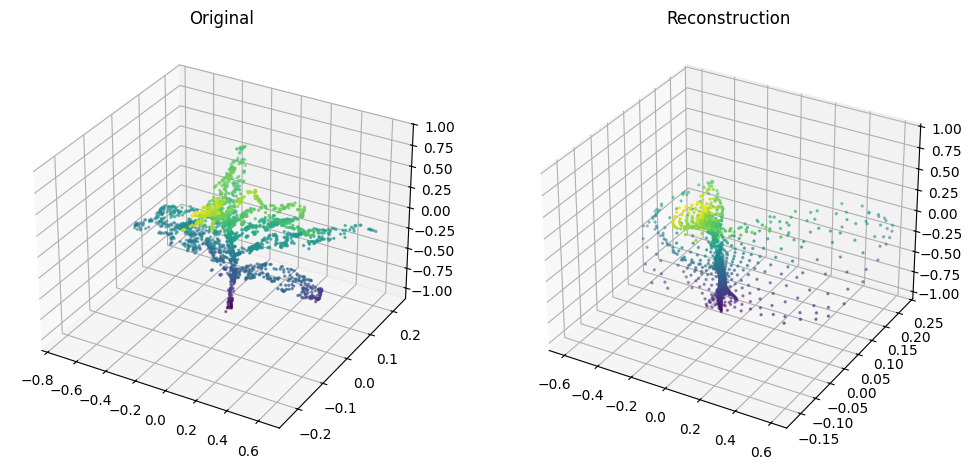

100%|██████████| 63/63 [00:05<00:00, 12.46it/s]


Epoch 276 Train 0.0029 Val 0.0052


100%|██████████| 63/63 [00:05<00:00, 11.71it/s]


Epoch 277 Train 0.0028 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.38it/s]


...

Epoch 298 Train 0.0027 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.54it/s]


Epoch 299 Train 0.0028 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 11.86it/s]


Epoch 300 Train 0.0027 Val 0.0053


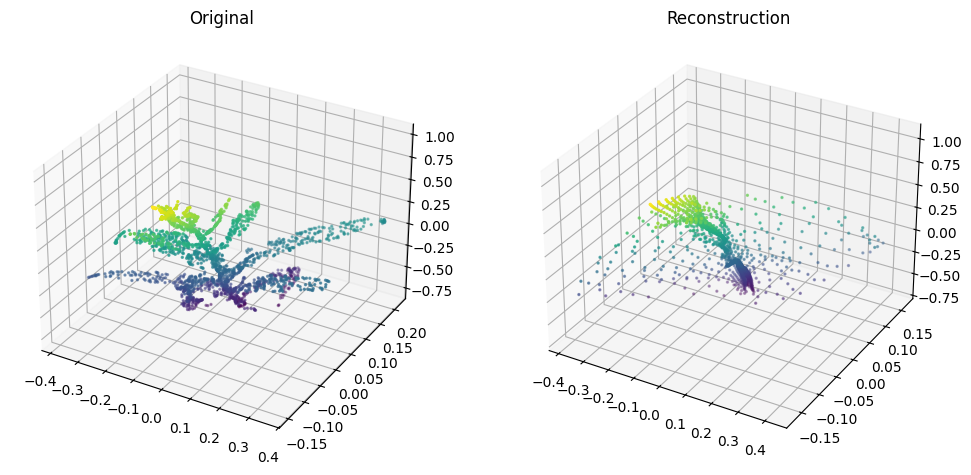

100%|██████████| 63/63 [00:04<00:00, 12.62it/s]


Epoch 301 Train 0.0027 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 11.93it/s]


Epoch 302 Train 0.0027 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.52it/s]


...

Epoch 323 Train 0.0026 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.42it/s]


Epoch 324 Train 0.0026 Val 0.0052


100%|██████████| 63/63 [00:05<00:00, 12.54it/s]


Epoch 325 Train 0.0025 Val 0.0053


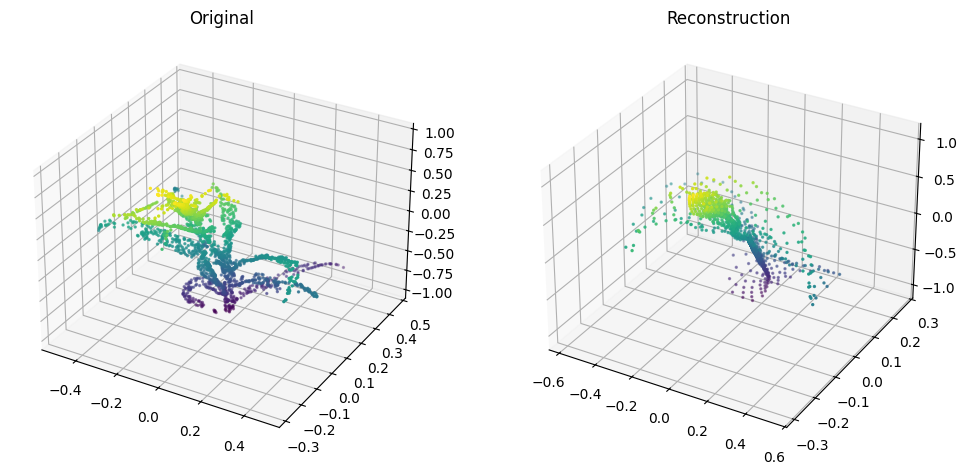

100%|██████████| 63/63 [00:05<00:00, 12.39it/s]


Epoch 326 Train 0.0027 Val 0.0053


100%|██████████| 63/63 [00:04<00:00, 12.66it/s]


Epoch 327 Train 0.0025 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.02it/s]


...

Epoch 348 Train 0.0026 Val 0.0052


100%|██████████| 63/63 [00:05<00:00, 11.96it/s]


Epoch 349 Train 0.0026 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.57it/s]


Epoch 350 Train 0.0024 Val 0.0052


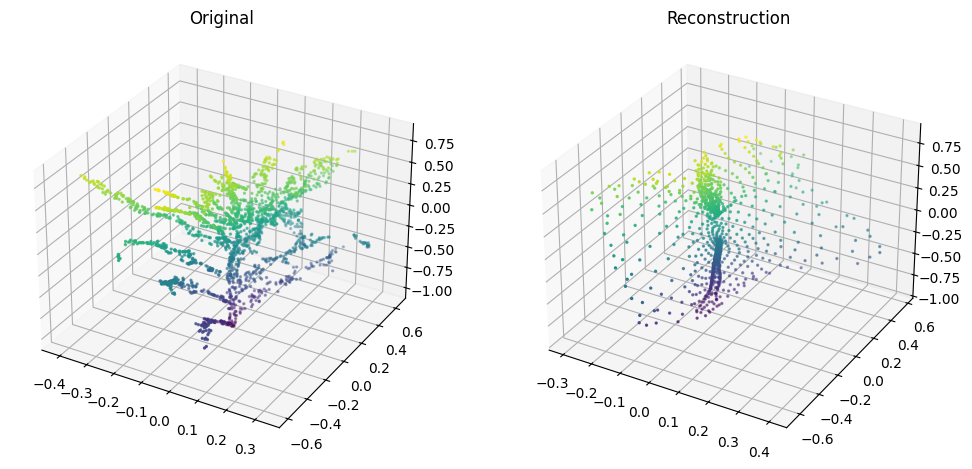

100%|██████████| 63/63 [00:05<00:00, 11.80it/s]


Epoch 351 Train 0.0024 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.51it/s]


Epoch 352 Train 0.0025 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.16it/s]


...

Epoch 373 Train 0.0026 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.41it/s]


Epoch 374 Train 0.0024 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.22it/s]


Epoch 375 Train 0.0024 Val 0.0053


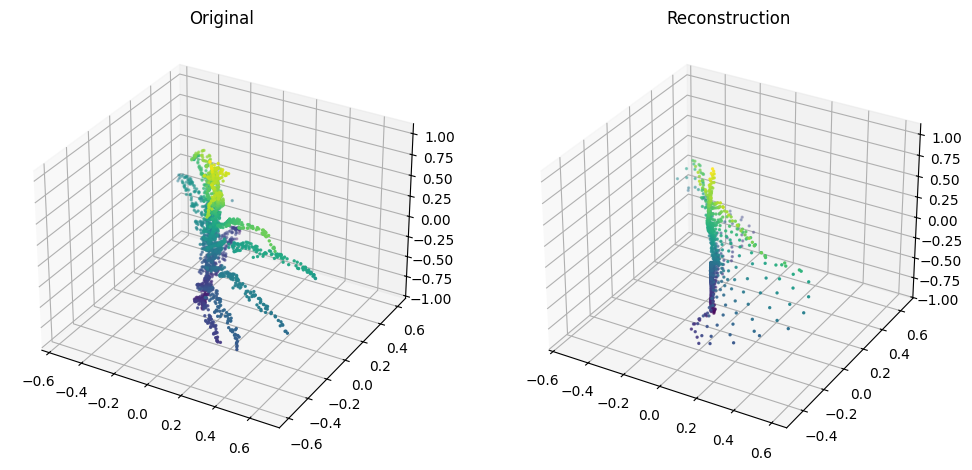

100%|██████████| 63/63 [00:05<00:00, 12.58it/s]


Epoch 376 Train 0.0024 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.04it/s]


Epoch 377 Train 0.0023 Val 0.0052


100%|██████████| 63/63 [00:05<00:00, 12.56it/s]


...

Epoch 398 Train 0.0024 Val 0.0053


100%|██████████| 63/63 [00:04<00:00, 12.66it/s]


Epoch 399 Train 0.0023 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.37it/s]


Epoch 400 Train 0.0024 Val 0.0053


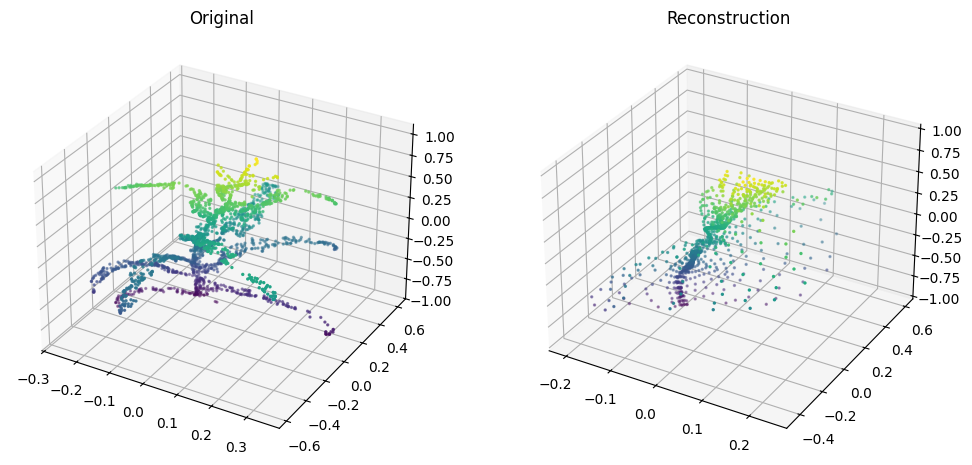

100%|██████████| 63/63 [00:04<00:00, 12.65it/s]


Epoch 401 Train 0.0023 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.33it/s]


Epoch 402 Train 0.0023 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.08it/s]


...

Epoch 423 Train 0.0023 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 11.86it/s]


Epoch 424 Train 0.0022 Val 0.0053


100%|██████████| 63/63 [00:04<00:00, 12.64it/s]


Epoch 425 Train 0.0022 Val 0.0052


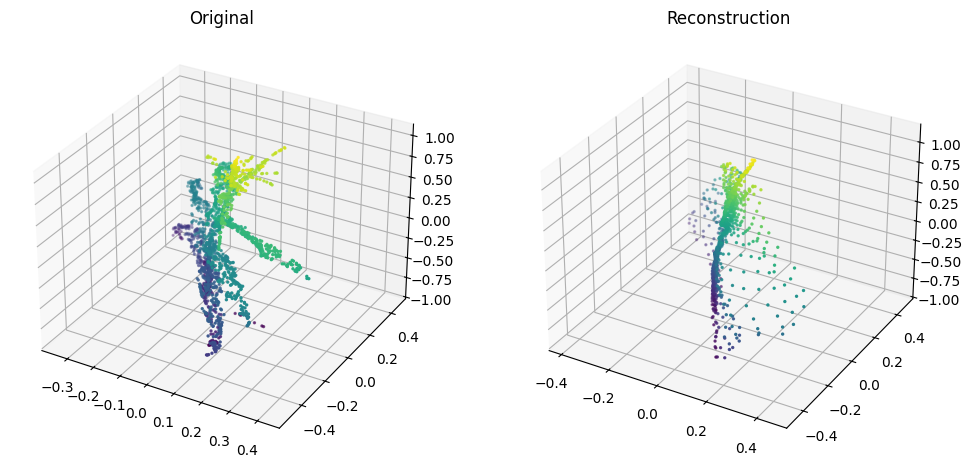

100%|██████████| 63/63 [00:05<00:00, 12.40it/s]


Epoch 426 Train 0.0022 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.32it/s]


Epoch 427 Train 0.0022 Val 0.0054


100%|██████████| 63/63 [00:04<00:00, 12.63it/s]


...

Epoch 448 Train 0.0022 Val 0.0052


100%|██████████| 63/63 [00:04<00:00, 12.61it/s]


Epoch 449 Train 0.0022 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 11.90it/s]


Epoch 450 Train 0.0022 Val 0.0053


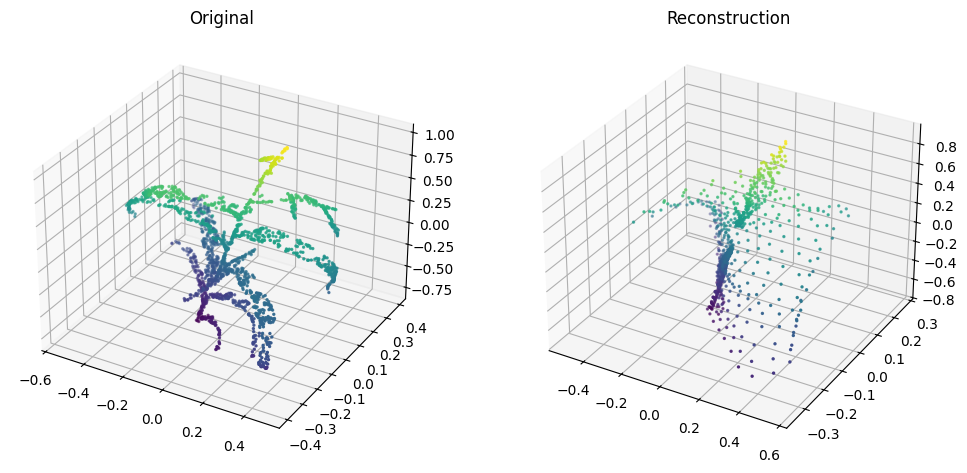

100%|██████████| 63/63 [00:04<00:00, 12.64it/s]


Epoch 451 Train 0.0022 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.31it/s]


Epoch 452 Train 0.0022 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.29it/s]


...

Epoch 473 Train 0.0022 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.14it/s]


Epoch 474 Train 0.0022 Val 0.0053


100%|██████████| 63/63 [00:04<00:00, 12.64it/s]


Epoch 475 Train 0.0021 Val 0.0054


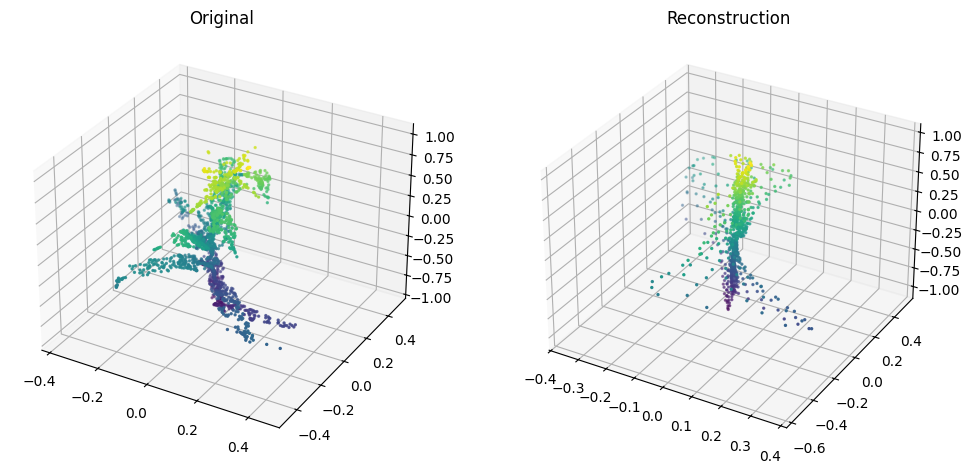

100%|██████████| 63/63 [00:05<00:00, 12.18it/s]


Epoch 476 Train 0.0021 Val 0.0053


100%|██████████| 63/63 [00:05<00:00, 12.15it/s]


Epoch 477 Train 0.0021 Val 0.0053


100%|██████████| 63/63 [00:04<00:00, 12.64it/s]


...

Epoch 497 Train 0.0021 Val 0.0052


100%|██████████| 63/63 [00:05<00:00, 11.69it/s]


Epoch 498 Train 0.0020 Val 0.0054


100%|██████████| 63/63 [00:05<00:00, 12.45it/s]


Epoch 499 Train 0.0021 Val 0.0053


In [ ]:
import math

for epoch in range(CFG["epochs"]):

    model.train()

    total_loss = 0

    for pc in tqdm(train_loader):

        pc = pc.to(DEVICE)

        recon = model(pc)

        loss = chamfer_loss(pc, recon)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    val_loss = evaluate(model, val_loader)

    print(f"Epoch {epoch} Train {train_loss:.4f} Val {val_loss:.4f}")

    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_loss_log": math.log(train_loss) if train_loss > 0 else float("nan"),
        "val_loss_log": math.log(val_loss) if val_loss > 0 else float("nan"),
    })

    if epoch % CFG["checkpoint_interval"] == 0:

        torch.save(model.state_dict(), f"checkpoint_epoch_{epoch}.pth")

        fig = visualize_reconstruction(model, val_dataset)

        wandb.log({
            "reconstruction": wandb.Image(fig),
            "epoch": epoch
        })

In [ ]:
test_loss = evaluate(model, test_loader)

print("Test Chamfer:", test_loss)

import math
wandb.log({
    "test_loss": test_loss,
    "test_loss_log": math.log(test_loss) if test_loss > 0 else float("nan"),
})

Test Chamfer: 0.005693752520815714


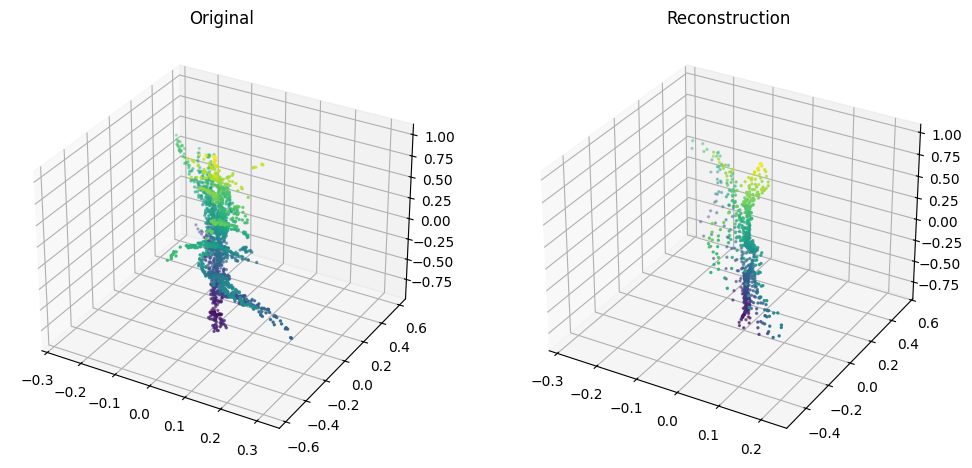

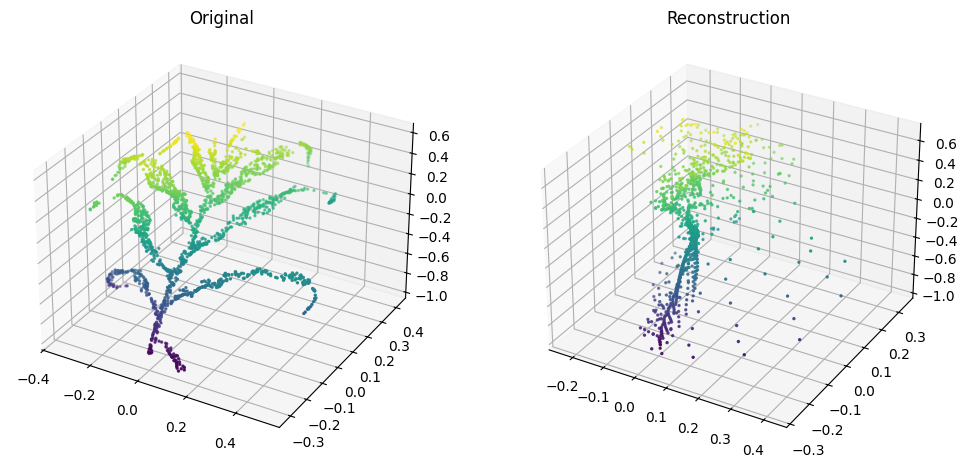

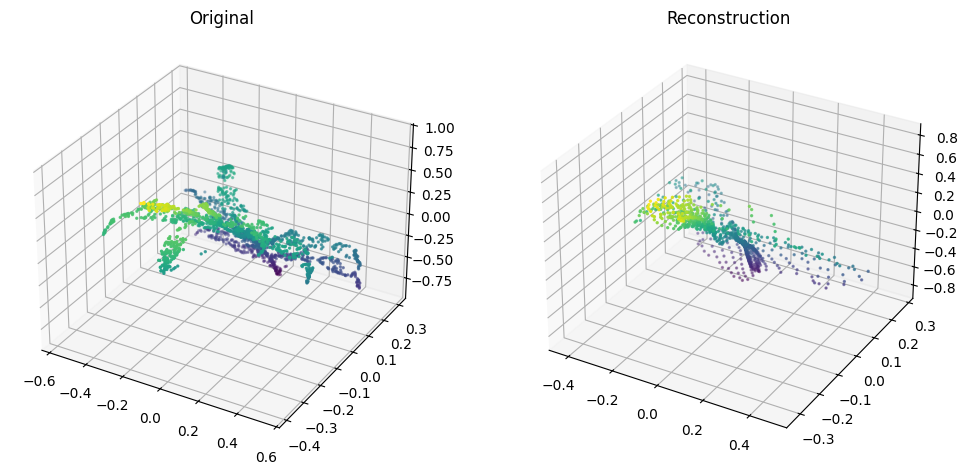

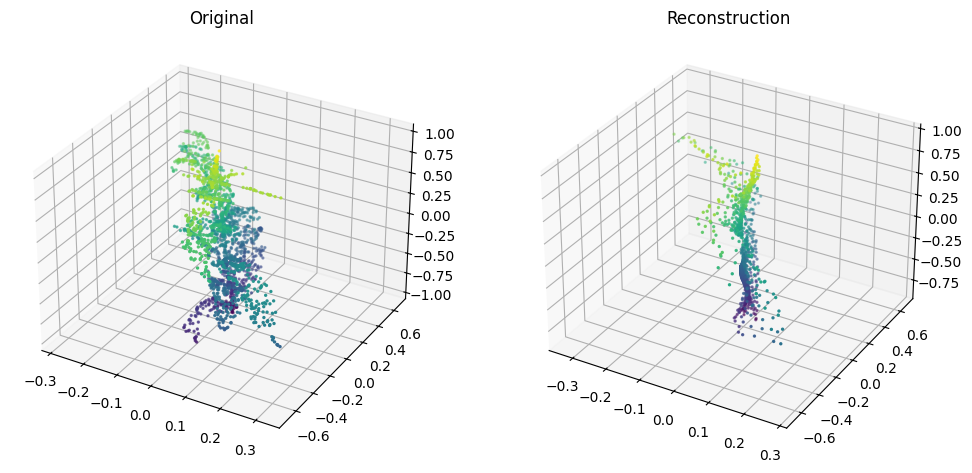

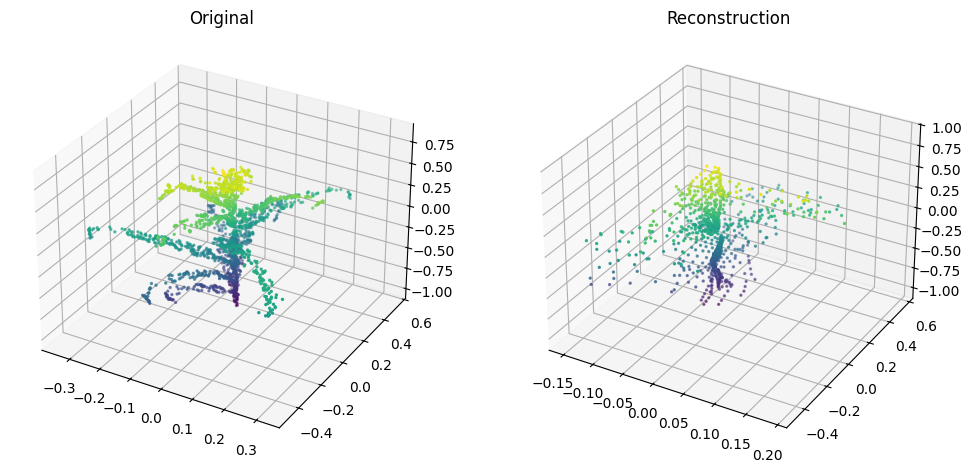

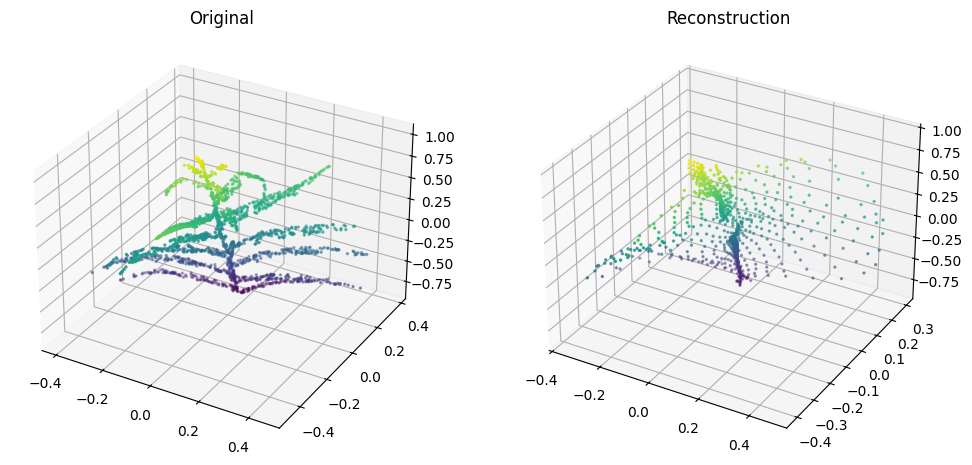

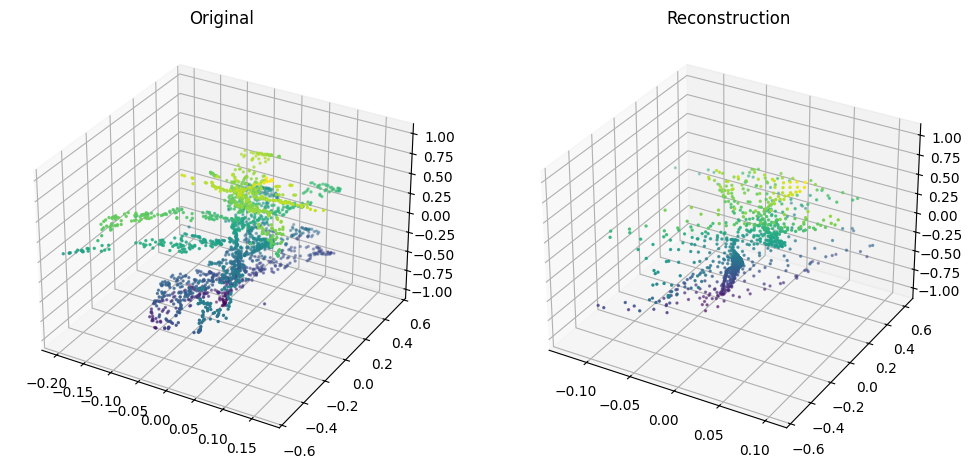

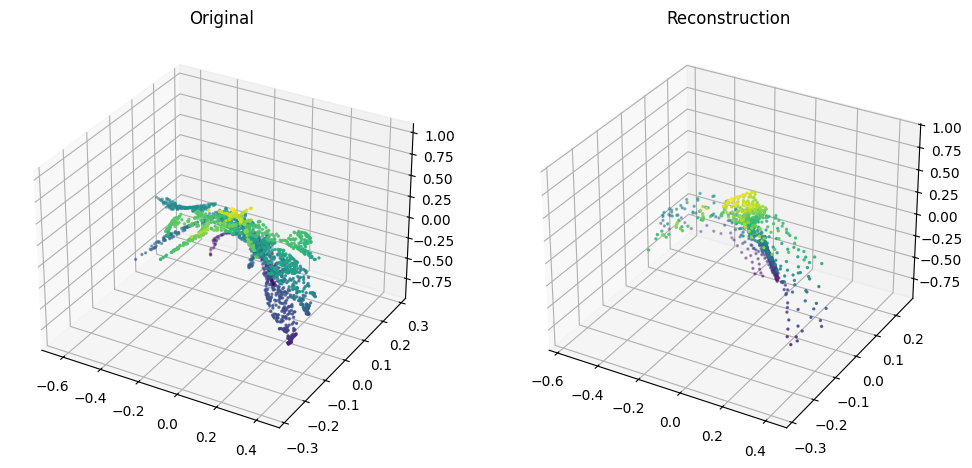

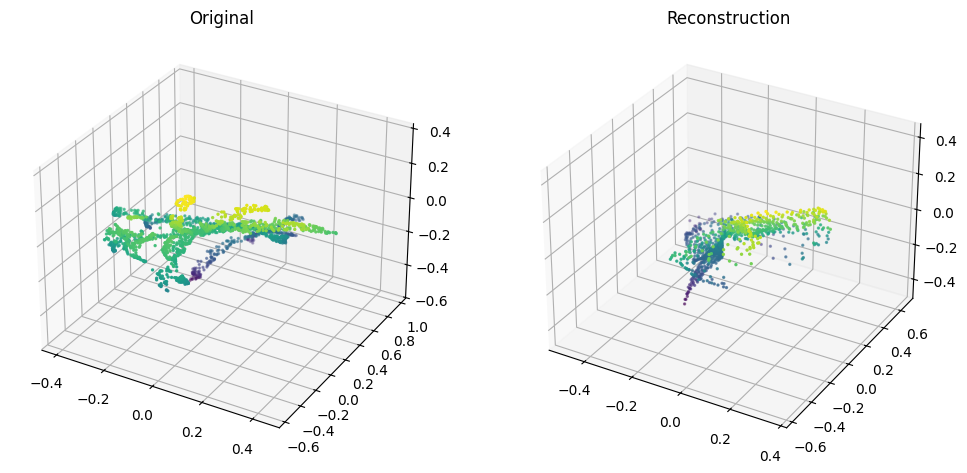

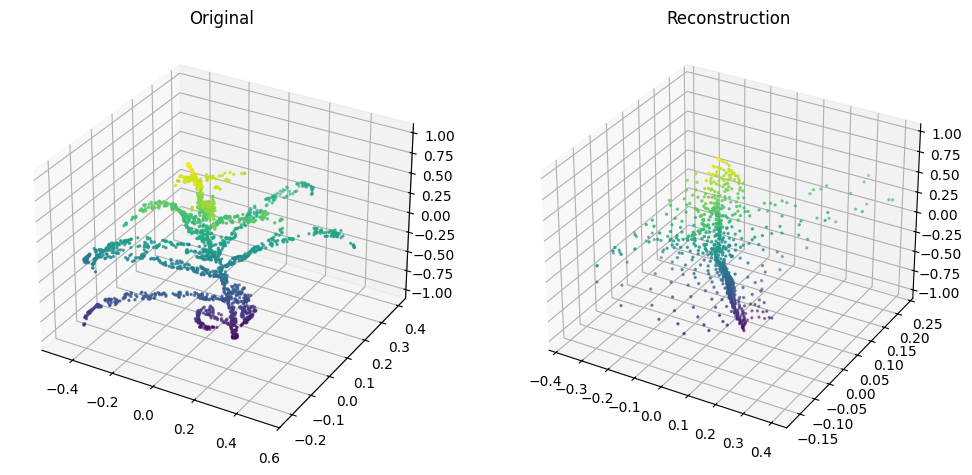

In [ ]:
for i in range(10):

    fig = visualize_reconstruction(model, test_dataset)

    wandb.log({"test_reconstruction": wandb.Image(fig)})